#### All Imports

In [ ]:
import os
from langgraph.graph import StateGraph, END, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing_extensions import TypedDict, Literal, Annotated
from langchain.messages import HumanMessage, SystemMessage, AnyMessage
from langgraph.graph.message import add_messages
from langchain.tools import tool
from tavily import TavilyClient
from pydantic import BaseModel, Field
from pprint import pprint
from IPython.display import Markdown, display, Image
from langgraph.prebuilt import ToolNode

In [ ]:
load_dotenv(".env")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [ ]:
basic_llm = ChatGroq(model="llama-3.1-8b-instant", api_key = GROQ_API_KEY, temperature=0)
advanced_llm = ChatGroq(model="llama-3.1-8b-instant", api_key = GROQ_API_KEY, temperature=0)

In [ ]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

In [ ]:
# Prompts - Read Content from Files
f = open("./prompts/generations.md")
GENERATION_PROMPT = f.read()
f = open("./prompts/optimisation.md")
OPTIMISATION_PROMPT = f.read()
f = open("./prompts/scoring.md")
SCORING_PROMPT = f.read()
f = open("./prompts/validation.md")
VALIDATION_PROMPT = f.read()

In [ ]:
class MarketingState(TypedDict):
    offre_rules: str
    customer_data: str
    score: str
    offre: str
    validation_feedback: str
    optimized_offre: str
    next: Literal["SCORING", "GENERATION", "VALIDATION", "OPTIMISATION", "END"]

#### Scoring Agent

In [ ]:
customer_data = """
        I have a client who spent 10 dollars on online shopping products during the last month.
        The client made 3 purchases, mainly buying electronics and accessories.
        Their average order value is around 3.33 dollars, and they usually purchase during weekends.
        The client has been active for 6 months and shows moderate engagement with marketing campaigns.
"""

def scoring_agent(state: MarketingState):
    print("Scoring Agent ...")
    customer_data = state.get("customer_data", "no customer data")
    messages = [HumanMessage(content=f"Customer Data: {customer_data}"), SystemMessage(content=SCORING_PROMPT)]
    score = basic_llm.invoke(messages)

    return {
        "score": score,
        "next": "GENERATION",
    }


In [ ]:
# Test Scroing Agent
state: MarketingState = {
    "customer_data": customer_data,
    "score": 0,
}
result = scoring_agent(state)
display(Markdown(result.get("score").content))

Scoring Agent ...


**Score: 42 / 100**
**Description:** The client has moderate spending habits, but their average order value is relatively low. They show some engagement with marketing campaigns, but their purchasing frequency and value are not consistent. Their weekend purchasing behavior may indicate a casual or impulse-driven shopper.

#### Generation Agent

In [ ]:
# Generation Agent
def generation_agent(state: MarketingState):
    print("Generation Agent ...")
    customer_data = state.get("customer_data", "no customer data")
    customer_score = state.get("score", "no score")
    offre_rules = state.get('offre_rules', "no offre rules")
    messages = [
        SystemMessage(content=GENERATION_PROMPT),
        HumanMessage(
            content=f"""
            Customer Data: \n\n
            {customer_data}
            
            Customer Score: \n\n
            {customer_score}
            
            Offre Rules: \n\n
            {offre_rules}
            """
        )
    ]
    offre = basic_llm.invoke(messages)
    return {
        "offre": offre,
        "next": "VALIDATION"
    }



In [ ]:
# Test Generation Agent
state: MarketingState = {
    "offre_rules": "discount between between 80% and 90% with code promo is WELCOME_TO_DIBORA.",
    "customer_data": customer_data,
    "offre": None,
    "score": "no score",
}
result = generation_agent(state)
display(Markdown(result.get("offre").content))

Generation Agent ...


**WELCOME_TO_DIBORA Exclusive Offer**

Get ready to upgrade your online shopping experience with Dibora!

As a valued customer, we're thrilled to offer you an exclusive 85% discount on your next purchase. Use code WELCOME_TO_DIBORA at checkout to redeem your discount.

**Your Benefits:**

- Enjoy a whopping 85% off on your favorite electronics and accessories
- Average order value of 3.33 dollars, now reduced to just 0.50 dollars
- Perfect opportunity to stock up on your weekend essentials

**Don't Miss Out!**

Redeem your discount now and experience the best of Dibora's online shopping world. Happy shopping!

#### Validation Agent

In [ ]:
rules = "no rules"
# Validation Agent
def validation_agent(state: MarketingState):
    print("Validation Agent ...")
    offre = state.get("offre", "no offre")
    offre_rules = state.get("offre_rules", "no offre polices")
    messages = [SystemMessage(content=VALIDATION_PROMPT), HumanMessage(content=
        f"""
        Offre: \n\n
            {offre}
        Offre Rules: \n\n
            {offre_rules}
        """
    )]

    response = basic_llm.invoke(messages)
    return {"validation_feedback": response, "next": "OPTIMISATION"}


In [ ]:
# Test Validation Agent
offre = """Bonjour Ahmed,
Nous sommes ravis de vous proposer une offre spéciale en votre nom !
Vous avez déjà dépensé 209,70€ chez nous
Nous avons remarqué que vous avez acheté des produits de qualité tels que des parfums, des chaussures et des t-shirts. Nous sommes convaincus que vous allez adorer notre nouvelle collection de produits de luxe !
Découvrez nos meilleures offres
Parfum exclusif : 50% de réduction sur notre nouveau parfum, disponible uniquement pendant une semaine !
Chaussures de luxe : 30% de réduction sur nos chaussures de luxe, conçues pour les pieds les plus exigeants !
T-shirt premium : 20% de réduction sur nos t-shirts premium, faits avec les matériaux les plus confortables !
N'oubliez pas de profiter de nos offres spéciales
Livraison gratuite : sur tous les commandes supérieures à 100€
Retour gratuit : sur tous les produits achetés chez nous
Cliquez ici pour découvrir nos offres [lien vers la page d'offres]
Nous sommes impatients de vous voir chez nous !
Cordialement, L'équipe de [votre nom de l'entreprise]
"""
# Test Validation Agent
state: MarketingState = {
    "offre": offre,
    "offre_rules": "the offre should be contain promo code DIBORA123",
    "client_data": customer_data,
}
result = validation_agent(state)
display(Markdown(result.get("validation_feedback").content))

Validation Agent ...


**Is Valid**: NOT VALID
**Description**: L'offre ne contient pas le code promo requis "DIBORA123".

#### Optimisation Offre

In [ ]:
# Agent for offre Optimisation
def optmisation_agent(state: MarketingState):
    print("Optimisation Agent ...")
    validation_feedback = state.get("validation_feedback", "no validation feedback")
    offre = state.get("offre", "no offre")
    messages = [SystemMessage(content=OPTIMISATION_PROMPT), HumanMessage(content=f"""
        Validation feedback: \n\n
            {validation_feedback}
        Original Offer: \n\n 
            {offre}
        """)]
    
    response = basic_llm.invoke(messages)
    return {"optimized_offre": response, "next": "END"}


In [ ]:
# Test Optimisation Agent
offre = """Bonjour Ahmed,
Nous sommes ravis de vous proposer une offre spéciale en votre nom !
Vous avez déjà dépensé 209,70€ chez nous
Nous avons remarqué que vous avez acheté des produits de qualité tels que des parfums, des chaussures et des t-shirts. Nous sommes convaincus que vous allez adorer notre nouvelle collection de produits de luxe !
Découvrez nos meilleures offres
Parfum exclusif : 50% de réduction sur notre nouveau parfum, disponible uniquement pendant une semaine !
Chaussures de luxe : 30% de réduction sur nos chaussures de luxe, conçues pour les pieds les plus exigeants !
T-shirt premium : 20% de réduction sur nos t-shirts premium, faits avec les matériaux les plus confortables !
N'oubliez pas de profiter de nos offres spéciales
Livraison gratuite : sur tous les commandes supérieures à 100€
Retour gratuit : sur tous les produits achetés chez nous
Cliquez ici pour découvrir nos offres [lien vers la page d'offres]
Nous sommes impatients de vous voir chez nous !
Cordialement, L'équipe de [votre nom de l'entreprise]
"""

# Test Optimisation Agent
state: MarketingState = {
    "offre": offre,
    "customer_data": customer_data,
    "validation_feedback": """Is Valid: NOT VALID Description: L'offre ne contient pas le code promo requis "DIBORA123""",
    "offre": offre,
}
result = optmisation_agent(state)
result
display(Markdown(result.get("optimized_offre").content))

Optimisation Agent ...


Bonjour Ahmed,

Nous sommes ravis de vous proposer une offre spéciale en votre nom ! En tant que client fidèle, vous avez déjà dépensé 209,70€ chez nous. Nous avons remarqué que vous avez acheté des produits de qualité tels que des parfums, des chaussures et des t-shirts. Nous sommes convaincus que vous allez adorer notre nouvelle collection de produits de luxe !

Pour profiter de cette offre, veuillez utiliser le code promo DIBORA123 lors de votre commande. Cela vous donnera accès à nos meilleures offres :

- Parfum exclusif : 50% de réduction sur notre nouveau parfum, disponible uniquement pendant une semaine !
- Chaussures de luxe : 30% de réduction sur nos chaussures de luxe, conçues pour les pieds les plus exigeants !
- T-shirt premium : 20% de réduction sur nos t-shirts premium, faits avec les matériaux les plus confortables !

N'oubliez pas de profiter de nos offres spéciales :

- Livraison gratuite : sur tous les commandes supérieures à 100€
- Retour gratuit : sur tous les produits achetés chez nous

Cliquez ici pour découvrir nos offres [lien vers la page d'offres] et n'oubliez pas d'utiliser le code promo DIBORA123 pour bénéficier de cette offre spéciale.

Nous sommes impatients de vous voir chez nous !

Cordialement,
L'équipe de [votre nom de l'entreprise]

#### Supervisor Agent

In [ ]:
# Supervisor agent
def supervisor_agent(state: MarketingState):
    print("Supervisor Agent ...")
    return state

#### Build graph

In [ ]:
def routerForSupervisor(state: MarketingState):
    return state.get("next", "END")

In [ ]:
workflow = StateGraph(MarketingState)

In [ ]:
workflow.add_node("supervisor_agent", supervisor_agent)
workflow.add_node("scoring_agent", scoring_agent)

workflow.add_edge("scoring_agent", "supervisor_agent")

workflow.add_node("generation_agent", generation_agent)
workflow.add_edge("generation_agent", "supervisor_agent")


workflow.add_node("validation_agent", validation_agent)
workflow.add_edge("validation_agent", "supervisor_agent")


workflow.add_node("optmisation_agent", optmisation_agent)
workflow.add_edge("optmisation_agent", "supervisor_agent")


workflow.set_entry_point("supervisor_agent")
workflow.add_conditional_edges("supervisor_agent", routerForSupervisor, 
    {
        "SCORING": "scoring_agent",
        "GENERATION": "generation_agent",
        "VALIDATION": "validation_agent",
        "OPTIMISATION": "optmisation_agent",
        "END": END
    }
)


In [ ]:
app = workflow.compile()

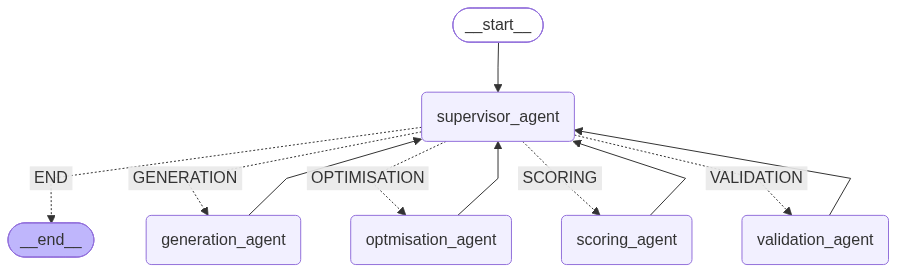

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

#### Test Workflow

In [ ]:
customer_data = """
        I have a client who spent 10 dollars on online shopping products during the last month.
        The client made 3 purchases, mainly buying electronics and accessories.
        Their average order value is around 3.33 dollars, and they usually purchase during weekends.
        The client has been active for 6 months and shows moderate engagement with marketing campaigns.
"""

state: MarketingState = {
    "offre_rules": "offre should under 200 words",
    "customer_data": "ERROR HERE",

    "score": "",
    "offre": "",
    "validation_feedback": "",
    "optimized_offre": "",
    "next": "SCORING"
}
final_state = app.invoke(state)

Supervisor Agent ...
Scoring Agent ...
Supervisor Agent ...
Generation Agent ...
Supervisor Agent ...
Validation Agent ...
Supervisor Agent ...
Optimisation Agent ...
Supervisor Agent ...


In [ ]:
print("CUSTOMER SCORE")
print(final_state.get("score").content)

CUSTOMER SCORE
**Score**: 0 / 100
**Description**: No customer data provided, unable to assess customer satisfaction.


In [ ]:
print("GENERATED OFFER")
print(final_state.get("offre").content)

GENERATED OFFER
**Marketing Offre**

No customer data provided, unable to generate a personalized offre. However, we can offer a general promotion to all customers.

**Limited Time Offer**

Get 20% off on your first purchase with us. Use code OFFRE20 at checkout. This offer is valid for a limited time only, so don't miss out. 

**Terms and Conditions**

- Offer valid for first-time customers only.
- Discount code can be used once per customer.
- Offer valid until [insert date].
- Not combinable with other promotions or discounts.


In [ ]:
print("VALIDATION FEEDBACK")
print(final_state.get("validation_feedback").content)

VALIDATION FEEDBACK
**Is Valid**: NOT VALID
**Description**: The Offre exceeds the 200-word limit specified in the Offre Rules.


In [ ]:
print("OPTIMIZED OFFER")
print(final_state.get("optimized_offre").content)

OPTIMIZED OFFER
**Marketing Offer**

Get ready to save big with our exclusive promotion. As a valued customer, we're offering you an unbeatable deal. 

**Limited Time Offer**

For a limited time only, enjoy 20% off your first purchase with us. Simply use code OFFRE20 at checkout to redeem your discount. Don't miss out on this incredible opportunity to save.

**Terms and Conditions**

- Offer valid for first-time customers only.
- Discount code can be used once per customer.
- Offer valid until [insert date, e.g., 12/31/2024].
- Not combinable with other promotions or discounts.

**Additional Details**

- This offer is exclusive to online purchases only.
- The discount code is case-sensitive and must be entered exactly as shown.
- If you have any questions or concerns, please don't hesitate to contact our customer support team.

**Hurry!** This offer won't last long, so be sure to take advantage of it today.
